# Notebook 03 — Análisis exploratorio y de negocio

**Proyecto:** Auditoría de desempeño y costo en una red de transporte terrestre
**Autor:** Sergio Corona

## Objetivo

Cuantificar oportunidades de ahorro y brechas de servicio sobre el dataset producido por
el pipeline del notebook 02, incorporando las tablas de eventos, reclamaciones,
licitaciones y dimensiones.

## Estructura

| Bloque | Contenido |
|---|---|
| 1 | Panorama de la red — volumen, gasto, mix, estacionalidad |
| 2 | Diagnóstico de servicio — OTD por modo, eventos y alcance de los hitos |
| 3 | Diagnóstico de costo — combustible, accesoriales, facturación |
| 4 | Scorecard de transportistas — costo real incluyendo reclamaciones |
| 5 | Oportunidades cuantificadas — modo, consolidación, licitaciones |
| 6 | Síntesis y caso de negocio |

## Insumos

`data/processed/02_shipments_limpio.pkl` más las tablas complementarias en `data/raw/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

RUTA_RAW = Path.cwd().parent / "data" / "raw"
RUTA_PROC = Path.cwd().parent / "data" / "processed"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

df = pd.read_pickle(RUTA_PROC / "02_shipments_limpio.pkl")

print(f"Embarques: {len(df):,} × {df.shape[1]} columnas")
print(f"Periodo  : {df['ship_date'].min():%Y-%m-%d} → {df['ship_date'].max():%Y-%m-%d}")
print(f"Gasto    : USD {df['total_cost_usd'].sum():,.0f}")


Embarques: 219,120 × 43 columnas
Periodo  : 2023-01-01 → 2026-06-30
Gasto    : USD 464,533,185


## 1. Panorama de la red

### 1.1 Carga de tablas complementarias

El pipeline del notebook 02 operó únicamente sobre `fact_shipments`. El análisis requiere
incorporar las dimensiones y las tablas de hechos restantes.

In [3]:
carrier = pd.read_csv(RUTA_RAW / "dim_carrier.csv")
site = pd.read_csv(RUTA_RAW / "dim_site.csv")
claims = pd.read_csv(RUTA_RAW / "fact_claims.csv")
rfp = pd.read_csv(RUTA_RAW / "fact_rfp_bids.csv")
fuel = pd.read_csv(RUTA_RAW / "dim_fuel_index.csv")
events = pd.read_csv(RUTA_RAW / "fact_shipment_events.csv")

for nombre, tabla in [
    ("dim_carrier", carrier),
    ("dim_site", site),
    ("fact_claims", claims),
    ("fact_rfp_bids", rfp),
    ("dim_fuel_index", fuel),
    ("fact_shipment_events", events),
]:
    print(f"{nombre:24} {len(tabla):>7,} filas × {tabla.shape[1]:>2} columnas")

dim_carrier                   30 filas ×  9 columnas
dim_site                      30 filas ×  8 columnas
fact_claims                2,089 filas ×  8 columnas
fact_rfp_bids              1,441 filas ×  8 columnas
dim_fuel_index               183 filas ×  3 columnas
fact_shipment_events     376,816 filas ×  3 columnas


In [4]:
for nombre, tabla in [
    ("dim_carrier", carrier),
    ("dim_site", site),
    ("fact_claims", claims),
    ("fact_rfp_bids", rfp),
    ("dim_fuel_index", fuel),
    ("fact_shipment_events", events),
]:
    print(f"\n{'='*70}\n{nombre}\n{'='*70}")
    print(tabla.head(3).to_string(index=False))



dim_carrier
carrier_id       carrier_name scac primary_mode carrier_tier carrier_country  cost_factor  service_factor  damage_factor
      C001    Ryder Logistics RYDR           TL    Strategic              US         1.00            0.00           1.00
      C002 Schneider National SCNN           TL    Strategic              US         0.97           -0.15           0.90
      C003 Werner Enterprises WERN           TL         Core              US         1.02            0.05           1.05

dim_site
site_id        site_name       city state country site_type    lat      lon
  USHAR    Harrisburg DC Harrisburg    PA      US        DC 40.273  -76.886
  USGRE Greensboro Plant Greensboro    NC      US     Plant 36.073  -79.792
  USFRE    Fremont Plant    Fremont    CA      US     Plant 37.548 -121.989

fact_claims
 claim_id shipment_id carrier_id claim_date claim_type  claim_amount_usd   claim_status  recovered_usd
CLM500000  SHP1164793       C017 2023-01-21   Shortage           1399.76 

In [5]:
panorama = (
    df.groupby("mode")
    .agg(
        embarques=("shipment_id", "count"),
        gasto_usd=("total_cost_usd", "sum"),
        costo_medio=("total_cost_usd", "mean"),
        peso_ton=("weight_kg", lambda s: s.sum() / 1000),
    )
    .sort_values("gasto_usd", ascending=False)
)

panorama["pct_embarques"] = panorama["embarques"] / panorama["embarques"].sum()
panorama["pct_gasto"] = panorama["gasto_usd"] / panorama["gasto_usd"].sum()

print(
    panorama.assign(
        gasto_usd=lambda d: d["gasto_usd"].map("{:,.0f}".format),
        costo_medio=lambda d: d["costo_medio"].map("{:,.0f}".format),
        peso_ton=lambda d: d["peso_ton"].map("{:,.0f}".format),
        pct_embarques=lambda d: d["pct_embarques"].map("{:.1%}".format),
        pct_gasto=lambda d: d["pct_gasto"].map("{:.1%}".format),
    ).to_string()
)

         embarques    gasto_usd costo_medio peso_ton pct_embarques pct_gasto
mode                                                                        
TL           41496  174,852,996       4,214  482,723         18.9%     37.6%
Ocean        17363   83,873,691       4,831  272,092          7.9%     18.1%
LTL          52519   77,054,287       1,467   52,586         24.0%     16.6%
Air          15182   65,840,830       4,337    5,446          6.9%     14.2%
Drayage       8704   37,327,545       4,289  120,037          4.0%      8.0%
Parcel       83856   25,583,837         305    1,327         38.3%      5.5%


### 1.2 Mix de modos

| Modo | Embarques | % embarques | Gasto USD | % gasto | Costo medio |
|---|---|---|---|---|---|
| TL | 41,496 | 18.9% | 174,852,996 | 37.6% | 4,214 |
| Ocean | 17,363 | 7.9% | 83,873,691 | 18.1% | 4,831 |
| LTL | 52,519 | 24.0% | 77,054,287 | 16.6% | 1,467 |
| Air | 15,182 | 6.9% | 65,840,830 | 14.2% | 4,337 |
| Drayage | 8,704 | 4.0% | 37,327,545 | 8.0% | 4,289 |
| Parcel | 83,856 | 38.3% | 25,583,837 | 5.5% | 305 |

**La distribución del gasto no sigue a la del volumen.** Parcel concentra 38.3% de los
embarques y 5.5% del gasto; TL y Ocean suman 26.8% de los embarques y 55.7% del gasto. La
priorización del análisis se orienta en consecuencia: una mejora porcentual sobre TL u
Ocean tiene un impacto que Parcel solo alcanzaría con volúmenes desproporcionados.

**Air presenta la peor relación entre costo y peso movido.** Con 5,446 toneladas y USD
65.8 M de gasto, el costo por tonelada asciende a 12,090 USD, frente a 308 de Ocean —una
diferencia de cuarenta veces—. Ese contraste define una línea de investigación: qué
proporción de la carga aérea responde a urgencia real y cuál es reasignable.

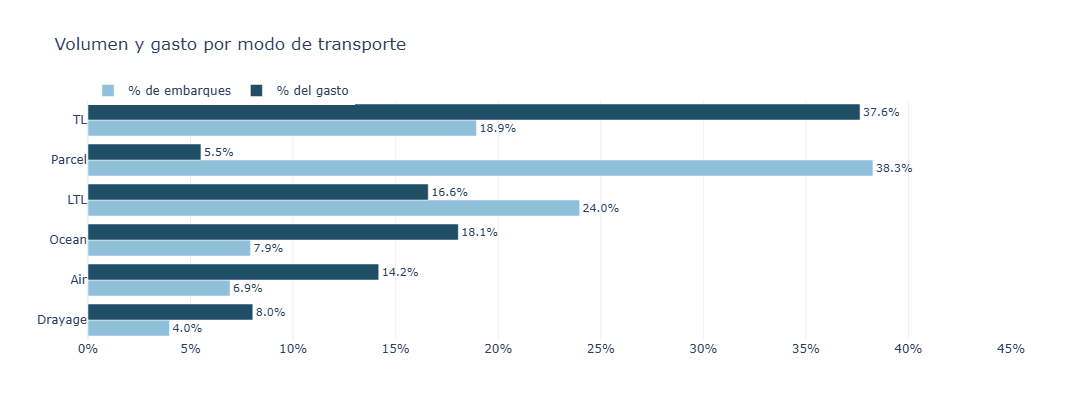

In [6]:
comp = (
    panorama[["pct_embarques", "pct_gasto"]]
    .reset_index()
    .melt(id_vars="mode", var_name="metrica", value_name="pct")
)
comp["metrica"] = comp["metrica"].map(
    {"pct_embarques": "% de embarques", "pct_gasto": "% del gasto"}
)

fig = px.bar(
    comp,
    x="pct",
    y="mode",
    color="metrica",
    barmode="group",
    orientation="h",
    text=comp["pct"].map("{:.1%}".format),
    color_discrete_map={"% de embarques": "#8FBFD9", "% del gasto": "#1F4E66"},
    labels={"pct": "", "mode": "", "metrica": ""},
    title="Volumen y gasto por modo de transporte",
)

fig.update_layout(
    template="plotly_white",
    height=420,
    legend=dict(orientation="h", y=1.1, x=0),
    xaxis=dict(tickformat=".0%", range=[0, 0.45]),
    yaxis=dict(categoryorder="total ascending"),
)
fig.update_traces(textposition="outside", textfont_size=11)
fig.show()

La gráfica hace visible lo que la tabla obliga a inferir: las barras de Parcel apuntan en
sentidos opuestos —la de volumen es la más larga del panel, la de gasto la más corta—
mientras que TL invierte la relación.

Air y Drayage muestran barras casi del mismo largo en ambas métricas, lo que indica que su
participación en el gasto es proporcional a su volumen. La desproporción se concentra en
los extremos.

### 1.3 Evolución temporal

El dataset documenta un crecimiento de volumen cercano al 28% y un pico estacional entre
septiembre y diciembre acompañado de deterioro en el nivel de servicio. Esta sección
verifica ambos patrones y establece la línea base temporal sobre la que se interpretan los
diagnósticos posteriores.

Se agrega por mes de despacho. El último periodo, junio de 2026, corresponde al corte del
dataset y no a una caída de actividad.

In [7]:
mensual = (
    df.assign(mes=df["ship_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes")
    .agg(
        embarques=("shipment_id", "count"),
        gasto_usd=("total_cost_usd", "sum"),
        otd=("otd", "mean"),
    )
    .reset_index()
)

print(f"Meses en la serie: {len(mensual)}  (esperado: 42)\n")

# Crecimiento: primer semestre 2023 vs. primer semestre 2026
h1_2023 = mensual.loc[mensual["mes"].dt.year == 2023].head(6)["embarques"].sum()
h1_2026 = mensual.loc[mensual["mes"].dt.year == 2026].head(6)["embarques"].sum()

print(f"Embarques ene–jun 2023 : {h1_2023:,}")
print(f"Embarques ene–jun 2026 : {h1_2026:,}")
print(f"Crecimiento            : {(h1_2026/h1_2023 - 1):.1%}")

# Estacionalidad
por_mes = (
    mensual.assign(mes_num=mensual["mes"].dt.month)
    .groupby("mes_num")
    .agg(embarques=("embarques", "mean"), otd=("otd", "mean"))
)
promedio = por_mes["embarques"].mean()
por_mes["indice"] = por_mes["embarques"] / promedio

print("\n--- Índice estacional (1.00 = mes promedio) ---")
print(
    por_mes.assign(
        embarques=lambda d: d["embarques"].map("{:,.0f}".format),
        otd=lambda d: d["otd"].map("{:.1%}".format),
        indice=lambda d: d["indice"].map("{:.2f}".format),
    ).to_string()
)

Meses en la serie: 42  (esperado: 42)

Embarques ene–jun 2023 : 26,372
Embarques ene–jun 2026 : 32,096
Crecimiento            : 21.7%

--- Índice estacional (1.00 = mes promedio) ---
        embarques    otd indice
mes_num                        
1           3,488  86.6%   0.66
2           3,407  85.4%   0.65
3           4,198  84.9%   0.80
4           5,054  87.6%   0.96
5           6,213  87.6%   1.18
6           6,793  87.4%   1.29
7           7,164  79.0%   1.36
8           6,928  83.1%   1.31
9           6,197  80.2%   1.17
10          5,650  81.0%   1.07
11          4,334  80.7%   0.82
12          3,898  81.2%   0.74


In [8]:
# Índice estacional calculado solo sobre años completos (2023, 2024, 2025)
completos = mensual[mensual["mes"].dt.year < 2026].copy()
completos["mes_num"] = completos["mes"].dt.month
completos["anio"] = completos["mes"].dt.year

# Se normaliza dentro de cada año para aislar la estacionalidad del crecimiento
completos["idx_anual"] = completos.groupby("anio")["embarques"].transform(
    lambda s: s / s.mean()
)

est = completos.groupby("mes_num").agg(
    indice=("idx_anual", "mean"),
    otd=("otd", "mean"),
)

print("--- Índice estacional sobre años completos (2023-2025) ---")
print(
    est.assign(
        indice=lambda d: d["indice"].map("{:.2f}".format),
        otd=lambda d: d["otd"].map("{:.1%}".format),
    ).to_string()
)
print(f"\nCorrelación índice vs. OTD: {est['indice'].corr(est['otd']):.3f}")

--- Índice estacional sobre años completos (2023-2025) ---
        indice    otd
mes_num              
1         0.65  85.9%
2         0.63  84.4%
3         0.78  84.4%
4         0.94  87.6%
5         1.17  87.6%
6         1.25  87.4%
7         1.38  79.0%
8         1.34  83.1%
9         1.19  80.2%
10        1.09  81.0%
11        0.84  80.7%
12        0.75  81.2%

Correlación índice vs. OTD: -0.169


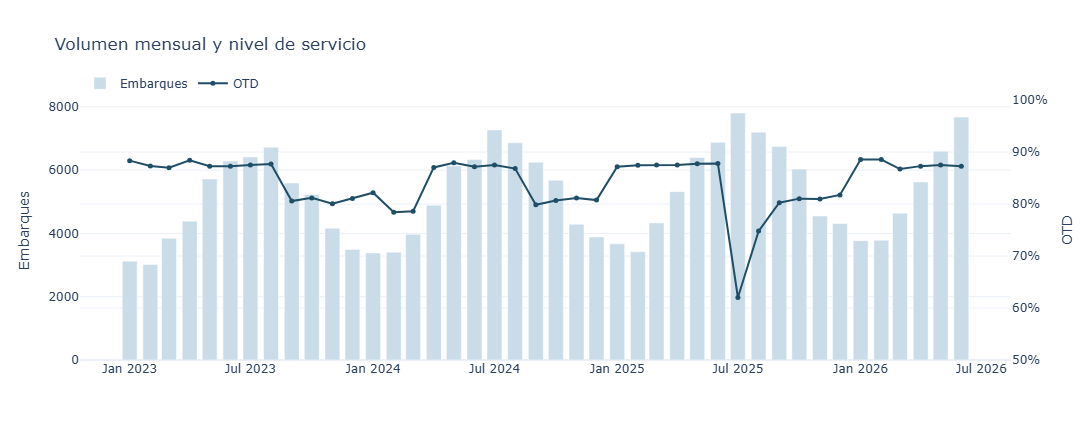

In [9]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=mensual["mes"], y=mensual["embarques"],
    name="Embarques", marker_color="#C9DCE8", yaxis="y",
))
fig.add_trace(go.Scatter(
    x=mensual["mes"], y=mensual["otd"],
    name="OTD", mode="lines+markers", line=dict(color="#1F4E66", width=2),
    marker=dict(size=5), yaxis="y2",
))

fig.update_layout(
    title="Volumen mensual y nivel de servicio",
    template="plotly_white", height=440,
    yaxis=dict(title="Embarques"),
    yaxis2=dict(title="OTD", overlaying="y", side="right", tickformat=".0%", range=[0.5, 1]),
    legend=dict(orientation="h", y=1.12, x=0),
    xaxis=dict(title=""),
)
fig.show()


**El deterioro del servicio responde a eventos, no a estacionalidad.**

El índice estacional de volumen es real y consistente entre años: pico en julio (1.38) y
agosto (1.34), valle en enero (0.65) y diciembre (0.75). Esto corrige la documentación del
dataset, que ubica el pico entre septiembre y diciembre.

La correlación entre índice de volumen y OTD es de −0.169, demasiado débil para sostener
una relación de saturación. La serie mensual explica por qué: el OTD se mantiene estable
alrededor del 87% frente a volúmenes que varían entre 3,400 y 7,800 embarques mensuales,
con dos interrupciones atribuibles a eventos concretos.

| Periodo | OTD | Duración | Evento asociado |
|---|---|---|---|
| Sep 2023 – Mar 2024 | 78–81% | 7 meses | Congestión portuaria |
| Jul – Ago 2025 | ~61% | 2 meses, recuperación de 4 | Paro de transportistas en México |

El desplome de julio de 2025 coincide con el mes de mayor volumen de toda la serie, lo que
podría sugerir saturación. La estabilidad del indicador en el resto del periodo descarta
esa lectura: agosto de 2024 registra 7,200 embarques con OTD de 87%, mientras que
noviembre de 2023 registra 4,100 con 80%.

**Implicación metodológica.** El promedio del OTD por mes calendario producía un perfil
estacional aparente —peor servicio en el segundo semestre— que resultaba ser un artefacto:
julio arrastraba el paro de 2025 y noviembre la congestión de 2023. Los indicadores de
servicio de esta red deben leerse sobre la serie temporal, no sobre agregados por mes
calendario, y los periodos afectados deben aislarse antes de establecer una línea base.

---

### Cierre del Bloque 1 — Panorama

La red mueve 219,120 embarques y USD 464.5 millones en tres años y medio, con un
crecimiento del 21.7% entre los primeros semestres de 2023 y 2026.

La estructura del gasto no sigue a la del volumen. Parcel concentra el 38.3% de los
embarques y el 5.5% del dinero; TL y Ocean invierten la relación con 26.8% del volumen y
55.7% del gasto. Cualquier iniciativa de ahorro debe dimensionarse sobre el gasto, no
sobre el conteo de embarques.

El costo por tonelada abre la línea de investigación más marcada del bloque: **Air cuesta
12,090 USD/ton contra 308 de Ocean, una relación de 40 a 1**. La diferencia es esperable
por la naturaleza de cada modo, pero su magnitud obliga a verificar qué proporción de la
carga aérea responde a urgencia real y cuál es reasignable.

El perfil estacional y la serie de servicio quedan caracterizados arriba: pico en
julio–agosto, y un OTD estable salvo por dos interrupciones atribuibles a eventos
concretos. El Bloque 2 desagrega ese indicador por modo para determinar dónde se origina
el incumplimiento.

## 2. Diagnóstico de servicio

### 2.1 El caso del modo Ocean

El notebook 02 registró un OTD de 66.71% para Ocean, casi quince puntos por debajo del
siguiente modo. La sección anterior identificó dos periodos de deterioro generalizado, uno
de ellos atribuible a congestión portuaria.

La pregunta es si el bajo desempeño de Ocean es una característica estructural del modo o
el efecto de un evento acotado en el tiempo que el promedio general absorbe.

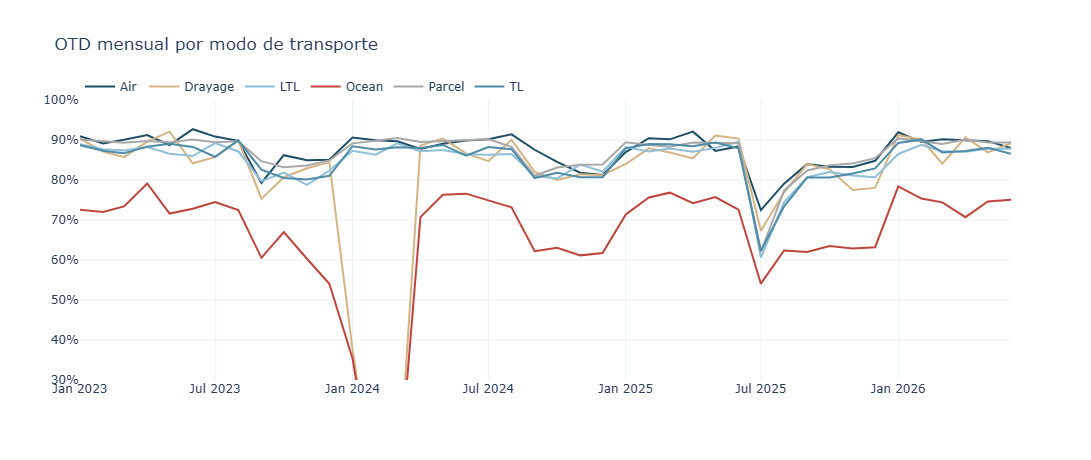

In [10]:
otd_modo_mes = (
    df.assign(mes=df["ship_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["mes", "mode"])["otd"]
    .mean()
    .reset_index()
)

fig = px.line(
    otd_modo_mes,
    x="mes", y="otd", color="mode",
    title="OTD mensual por modo de transporte",
    labels={"otd": "", "mes": "", "mode": ""},
    color_discrete_map={
        "Ocean": "#C1443C", "Air": "#1F4E66", "TL": "#4E8CA8",
        "LTL": "#8FBFD9", "Parcel": "#A8A8A8", "Drayage": "#D4B483",
    },
)

fig.update_layout(
    template="plotly_white", height=460,
    yaxis=dict(tickformat=".0%", range=[0.3, 1]),
    legend=dict(orientation="h", y=1.1, x=0),
    hovermode="x unified",
)
fig.update_traces(line_width=2)
fig.show()

In [11]:
foco = (
    df[df["mode"].isin(["Ocean", "Drayage"])]
    .assign(mes=df["ship_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["mes", "mode"])
    .agg(embarques=("shipment_id", "count"), otd=("otd", "mean"))
    .reset_index()
)

print("--- Drayage, dic 2023 a mar 2024 ---")
print(
    foco[
        (foco["mode"] == "Drayage")
        & (foco["mes"] >= "2023-11-01")
        & (foco["mes"] <= "2024-04-01")
    ]
    .assign(otd=lambda d: d["otd"].map("{:.1%}".format))
    .to_string(index=False)
)

print("\n--- Ocean: OTD por año ---")
print(
    df[df["mode"] == "Ocean"]
    .assign(anio=df["ship_date"].dt.year)
    .groupby("anio")
    .agg(embarques=("shipment_id", "count"), otd=("otd", "mean"))
    .assign(otd=lambda d: d["otd"].map("{:.1%}".format))
    .to_string()
)

--- Drayage, dic 2023 a mar 2024 ---
       mes    mode  embarques   otd
2023-11-01 Drayage        168 82.9%
2023-12-01 Drayage        149 84.5%
2024-01-01 Drayage        154 37.7%
2024-02-01 Drayage        136  0.0%
2024-03-01 Drayage        166  0.0%
2024-04-01 Drayage        187 88.6%

--- Ocean: OTD por año ---
      embarques    otd
anio                  
2023       4567  69.6%
2024       4965  59.8%
2025       5275  66.9%
2026       2556  74.5%


In [12]:
comp = (
    df.groupby("mode")
    .agg(
        transito_plan=("planned_transit_days", "median"),
        transito_real=("actual_transit_days", "median"),
        retraso_h=("retraso_horas", "median"),
        otd=("otd", "mean"),
    )
    .round(2)
    .sort_values("otd")
)
comp["desvio_dias"] = (comp["transito_real"] - comp["transito_plan"]).round(2)

print(
    comp.assign(otd=lambda d: d["otd"].map("{:.1%}".format)).to_string()
)

         transito_plan  transito_real  retraso_h    otd  desvio_dias
mode                                                                
Ocean             26.0          26.25       0.00  67.0%         0.25
Drayage            8.0           8.10     -16.08  81.0%         0.10
LTL                6.0           5.48     -18.24  84.0%        -0.52
TL                 5.0           4.73     -18.96  85.0%        -0.27
Parcel             5.0           4.07     -21.60  86.0%        -0.93
Air                3.0           2.11     -22.08  87.0%        -0.89


### 2.2 El bajo OTD de Ocean es un problema de planeación

El desempeño de Ocean es estructural, no consecuencia de un evento. Su OTD se mantiene
entre quince y veinticinco puntos por debajo de los demás modos durante los 42 meses de la
serie, y ningún año se acerca a la línea base de la red:

| Año | Embarques | OTD |
|---|---|---|
| 2023 | 4,567 | 69.6% |
| 2024 | 4,965 | 59.8% |
| 2025 | 5,275 | 66.9% |
| 2026 | 2,556 | 74.5% |

La causa se identifica al comparar el margen de entrega por modo:

| Modo | Tránsito planeado | Tránsito real | Retraso mediano | OTD |
|---|---|---|---|---|
| Ocean | 26.0 d | 26.25 d | **0.00 h** | 67.0% |
| Drayage | 8.0 d | 8.10 d | −16.08 h | 81.0% |
| LTL | 6.0 d | 5.48 d | −18.24 h | 84.0% |
| TL | 5.0 d | 4.73 d | −18.96 h | 85.0% |
| Parcel | 5.0 d | 4.07 d | −21.60 h | 86.0% |
| Air | 3.0 d | 2.11 d | −22.08 h | 87.0% |

**La relación entre margen y cumplimiento es monótona en los seis modos.** Air entrega
mediana de 22 horas antes del compromiso y alcanza 87% de OTD; Ocean entrega exactamente
en el plazo y alcanza 67%.

El indicador de Ocean no mide una operación deficiente sino la ausencia de holgura en el
compromiso. Con un retraso mediano de cero, la mitad de los embarques queda por encima del
plazo y solo la tolerancia de 12 horas evita que el OTD caiga más. Cualquier variabilidad
operativa se traduce directamente en incumplimiento.

**Implicación.** Elevar el OTD de Ocean no requiere intervenir la operación marítima sino
recalibrar los tiempos comprometidos. Un ajuste que otorgara a Ocean el mismo margen
relativo que tiene el resto de la red desplazaría su cumplimiento sin cambiar un solo día
de tránsito real. La pregunta para el negocio es si ese compromiso se fijó sobre datos
históricos o se heredó de un supuesto no verificado.

### 2.3 Interrupción total del servicio de drayage

El análisis mensual revela un episodio que el promedio anual oculta:

| Mes | Embarques | OTD |
|---|---|---|
| Nov 2023 | 168 | 82.9% |
| Dic 2023 | 149 | 84.5% |
| **Ene 2024** | 154 | **37.7%** |
| **Feb 2024** | 136 | **0.0%** |
| **Mar 2024** | 166 | **0.0%** |
| Abr 2024 | 187 | 88.6% |

Durante febrero y marzo de 2024, ninguno de los 302 embarques de drayage llegó a tiempo.
El volumen se mantuvo en niveles normales, lo que descarta un artefacto de muestra
reducida: la operación siguió despachando y ningún embarque cumplió.

El drayage traslada contenedores desde puerto, por lo que es el modo directamente expuesto
a la congestión portuaria documentada para ese periodo. La recuperación es abrupta —de 0%
a 88.6% en un mes— lo que sugiere la resolución de un cuello de botella puntual antes que
una mejora gradual de desempeño.

### 2.4 Distribución del tiempo entre hitos

`fact_shipment_events` registra el paso de cada embarque por cinco hitos: recolección,
tránsito, despacho aduanal, salida a reparto y entrega. La tabla contiene 376,816 eventos
para 219,120 embarques, un promedio de 1.7 por embarque, lo que indica que la cobertura no
es uniforme.

Antes de medir tiempos entre hitos es necesario establecer qué proporción de los embarques
tiene una secuencia completa y si la cobertura difiere por modo. Un análisis de cuellos de
botella sobre una muestra sesgada llevaría a conclusiones que no aplican al total.

In [13]:
print("--- Tipos de evento ---")
print(events["event_type"].value_counts().to_string())

cobertura = events.groupby("shipment_id")["event_type"].nunique()
print(f"\n--- Hitos por embarque ---")
print(cobertura.value_counts().sort_index().to_string())

print(f"\nEmbarques en la tabla de eventos: {events['shipment_id'].nunique():,}")
print(f"Embarques en el dataset limpio  : {df['shipment_id'].nunique():,}")

--- Tipos de evento ---
event_type
PICKED_UP           90000
IN_TRANSIT          90000
OUT_FOR_DELIVERY    90000
DELIVERED           90000
CUSTOMS_CLEARED     16816

--- Hitos por embarque ---
event_type
4    73184
5    16816

Embarques en la tabla de eventos: 90,000
Embarques en el dataset limpio  : 219,120


In [14]:
con_eventos = set(events["shipment_id"])
df_ev = df.assign(tiene_eventos=df["shipment_id"].isin(con_eventos))

print("--- Cobertura por modo ---")
print(
    df_ev.groupby("mode")["tiene_eventos"]
    .agg(["sum", "count", "mean"])
    .assign(mean=lambda d: d["mean"].map("{:.1%}".format))
    .rename(columns={"sum": "con_eventos", "count": "total", "mean": "cobertura"})
    .to_string()
)

print("\n--- Cobertura por año ---")
print(
    df_ev.assign(anio=df["ship_date"].dt.year)
    .groupby("anio")["tiene_eventos"]
    .mean()
    .map("{:.1%}".format)
    .to_string()
)

print("\n--- ¿Difiere el OTD entre ambos grupos? ---")
print(
    df_ev.groupby("tiene_eventos")["otd"]
    .agg(["mean", "count"])
    .assign(mean=lambda d: d["mean"].map("{:.1%}".format))
    .to_string()
)

--- Cobertura por modo ---
         con_eventos  total cobertura
mode                                 
Air             6183  15182     40.7%
Drayage         3523   8704     40.5%
LTL            21490  52519     40.9%
Ocean           7029  17363     40.5%
Parcel         34352  83856     41.0%
TL             17061  41496     41.1%

--- Cobertura por año ---
anio
2023    41.1%
2024    40.7%
2025    40.8%
2026    41.1%

--- ¿Difiere el OTD entre ambos grupos? ---
                mean   count
tiene_eventos               
False          83.9%  128445
True           84.0%   88932


**La cobertura de eventos corresponde a una muestra aleatoria.** De los 219,120 embarques,
90,000 (41.1%) tienen registro de hitos. La proporción se mantiene entre 40.5% y 41.1% en
los seis modos y entre 40.7% y 41.1% en los cuatro años.

El OTD de ambos grupos es indistinguible —83.9% sin eventos frente a 84.0% con eventos—,
lo que descarta que la muestra recoja embarques con características particulares. Los
tiempos entre hitos medidos sobre este subconjunto son extrapolables al total.

Las secuencias están completas: 73,184 embarques registran cuatro hitos y 16,816 registran
cinco. La diferencia corresponde a `CUSTOMS_CLEARED`, el único hito que no aparece en toda
la muestra. La sección 2.6 determina a qué condición responde su presencia. No existen
secuencias truncadas.

### 2.5 Dónde se acumula el tiempo

Con la secuencia de hitos es posible descomponer el tránsito total en tramos y determinar
en cuál se concentra el tiempo. La pregunta operativa es distinta a la del OTD: no cuánto
se tardó un embarque, sino en qué punto de la cadena.

Los eventos se pivotean a formato ancho para calcular las diferencias entre hitos
consecutivos.

In [15]:
ev = events.copy()
ev["event_ts"] = pd.to_datetime(ev["event_ts"]).astype("datetime64[us]")

hitos = ev.pivot_table(
    index="shipment_id", columns="event_type", values="event_ts", aggfunc="first"
)

tramos = pd.DataFrame(index=hitos.index)
tramos["recoleccion_a_transito"] = (
    hitos["IN_TRANSIT"] - hitos["PICKED_UP"]
).dt.total_seconds() / 3600
tramos["transito_a_reparto"] = (
    hitos["OUT_FOR_DELIVERY"] - hitos["IN_TRANSIT"]
).dt.total_seconds() / 3600
tramos["reparto_a_entrega"] = (
    hitos["DELIVERED"] - hitos["OUT_FOR_DELIVERY"]
).dt.total_seconds() / 3600
tramos["total"] = (
    hitos["DELIVERED"] - hitos["PICKED_UP"]
).dt.total_seconds() / 3600

tramos = tramos.join(df.set_index("shipment_id")[["mode", "otd"]], how="inner")

print(f"Embarques analizables: {len(tramos):,}\n")
print("--- Horas por tramo (mediana) ---")
print(
    tramos.groupby("mode")[
        ["recoleccion_a_transito", "transito_a_reparto", "reparto_a_entrega", "total"]
    ]
    .median()
    .round(1)
    .to_string()
)

Embarques analizables: 89,638

--- Horas por tramo (mediana) ---
         recoleccion_a_transito  transito_a_reparto  reparto_a_entrega  total
mode                                                                         
Air                        17.9                29.6                3.6   51.1
Drayage                    68.5               113.4               13.7  195.6
LTL                        46.1                76.4                9.2  131.8
Ocean                     221.3               366.7               44.3  632.2
Parcel                     34.2                56.7                6.8   97.7
TL                         39.5                65.4                7.9  112.8


In [16]:
prop = tramos.copy()
for c in ["recoleccion_a_transito", "transito_a_reparto", "reparto_a_entrega"]:
    prop[c + "_pct"] = prop[c] / prop["total"]

cols = [c + "_pct" for c in ["recoleccion_a_transito", "transito_a_reparto", "reparto_a_entrega"]]

print("--- Dispersión de la proporción por tramo ---")
print(prop[cols].describe().round(4).to_string())

print("\n--- ¿Difiere entre embarques a tiempo y tardíos? ---")
print(prop.groupby("otd")[cols].median().round(4).to_string())

--- Dispersión de la proporción por tramo ---
       recoleccion_a_transito_pct  transito_a_reparto_pct  reparto_a_entrega_pct
count                    89638.00                89638.00               89638.00
mean                         0.35                    0.58                   0.07
std                          0.00                    0.00                   0.00
min                          0.35                    0.58                   0.07
25%                          0.35                    0.58                   0.07
50%                          0.35                    0.58                   0.07
75%                          0.35                    0.58                   0.07
max                          0.35                    0.58                   0.07

--- ¿Difiere entre embarques a tiempo y tardíos? ---
       recoleccion_a_transito_pct  transito_a_reparto_pct  reparto_a_entrega_pct
otd                                                                             
False    

**Los tiempos entre hitos no admiten análisis de cuellos de botella.**

La descomposición del tránsito arroja proporciones idénticas en los seis modos:

| Modo | Recolección → tránsito | Tránsito → reparto | Reparto → entrega | Total |
|---|---|---|---|---|
| Air | 35.0% | 58.0% | 7.0% | 51.1 h |
| Parcel | 35.0% | 58.0% | 7.0% | 97.7 h |
| TL | 35.0% | 58.0% | 7.0% | 112.8 h |
| LTL | 35.0% | 58.0% | 7.0% | 131.8 h |
| Drayage | 35.2% | 58.3% | 7.0% | 195.6 h |
| Ocean | 35.0% | 58.0% | 7.0% | 632.2 h |

Sobre los 89,638 embarques con secuencia completa, la desviación estándar de las tres
proporciones es 0.00, y el mínimo coincide con el máximo. La composición tampoco difiere
entre embarques puntuales y tardíos.

**Interpretación.** Los hitos se generaron aplicando porcentajes fijos sobre el tiempo
total de tránsito, no simulando una operación. En una red real la composición varía por
modo —un embarque marítimo concentra su tiempo en el trayecto, mientras que el drayage
acumula espera en puerto— y varía entre embarques puntuales y tardíos, que es precisamente
lo que permitiría localizar un cuello de botella.

Reportar que el tramo de tránsito concentra el 58% del tiempo sería exacto y carente de
valor analítico: es un parámetro de generación, no un hallazgo.

**Decisión.** El análisis de hitos se descarta como línea de investigación. Queda una
excepción por revisar antes de cerrar el bloque: `CUSTOMS_CLEARED` es el único hito con
presencia condicionada, y un hito condicionado pudo generarse con lógica propia.

### 2.6 Despacho aduanal: el único hito con presencia condicionada

El análisis de tiempos entre hitos se descartó porque la composición del tránsito resultó
ser un parámetro fijo de generación. Queda una excepción que merece revisión antes de
cerrar el bloque.

Los cuatro hitos base —`PICKED_UP`, `IN_TRANSIT`, `OUT_FOR_DELIVERY`, `DELIVERED`— están
presentes en toda la muestra con eventos. `CUSTOMS_CLEARED` no: aparece en 16,816 de los
89,638 embarques con secuencia completa. Su presencia depende de una condición del
embarque, no del muestreo.

Esa diferencia importa. Un hito condicionado pudo generarse con lógica propia, y en ese
caso el tiempo de despacho tendría variación real por corredor, por modo o por
transportista. Si en cambio replica el mismo patrón de porcentaje fijo, la línea queda
cerrada por completo y el bloque puede pasar a costo.

**Lo que se verifica:**

1. Que la presencia del hito corresponda efectivamente a embarques con cruce fronterizo
  (`origin_country != dest_country`) y no a otra condición.
2. Qué proporción del tránsito total ocupa el tramo hasta el despacho.
3. Si esa proporción se dispersa —por corredor, modo y transportista— o vuelve a colapsar
  en un valor único.

El criterio de decisión es el mismo del bloque anterior: desviación estándar cercana a
cero significa parámetro de generación, no operación.

In [18]:
# --- Verificación 1: ¿a qué condición responde la presencia de CUSTOMS_CLEARED? ---

# Universo: embarques que SÍ tienen registro de eventos
ids_con_eventos = set(events["shipment_id"].unique())
ids_con_aduana  = set(events.loc[events["event_type"] == "CUSTOMS_CLEARED", "shipment_id"].unique())

print(f"Embarques con eventos      : {len(ids_con_eventos):,}")
print(f"Embarques con CUSTOMS_CLEARED: {len(ids_con_aduana):,}")

# Nos restringimos al universo con eventos y marcamos las dos condiciones
aud = df.loc[df["shipment_id"].isin(ids_con_eventos), 
             ["shipment_id", "mode", "origin_country", "dest_country", "carrier_id"]].copy()

aud["cruce_frontera"] = aud["origin_country"] != aud["dest_country"]
aud["tiene_aduana"]   = aud["shipment_id"].isin(ids_con_aduana)

print(f"\nEmbarques del universo localizados en df: {len(aud):,}")

print("\n--- Cruce de frontera vs. presencia del hito ---")
tabla = pd.crosstab(aud["cruce_frontera"], aud["tiene_aduana"], margins=True)
print(tabla)

# Los dos casos que romperían la correspondencia
falsos_neg = aud[aud["cruce_frontera"] & ~aud["tiene_aduana"]]
falsos_pos = aud[~aud["cruce_frontera"] & aud["tiene_aduana"]]

print(f"\nCross-border SIN hito de aduana : {len(falsos_neg):,}")
print(f"Domestico CON hito de aduana    : {len(falsos_pos):,}")

if len(falsos_neg):
    print("\n--- Cross-border sin hito, por modo ---")
    print(falsos_neg["mode"].value_counts())

print("\n--- Corredores con hito de aduana ---")
print(aud[aud["tiene_aduana"]]
      .groupby(["origin_country", "dest_country"], observed=True)
      .size().sort_values(ascending=False))

Embarques con eventos      : 90,000
Embarques con CUSTOMS_CLEARED: 16,816

Embarques del universo localizados en df: 89,638

--- Cruce de frontera vs. presencia del hito ---
tiene_aduana    False   True    All
cruce_frontera                     
False           28068   6773  34841
True            44835   9962  54797
All             72903  16735  89638

Cross-border SIN hito de aduana : 44,835
Domestico CON hito de aduana    : 6,773

--- Cross-border sin hito, por modo ---
mode
Parcel    21192
LTL       13197
TL        10446
Name: count, dtype: int64

--- Corredores con hito de aduana ---
origin_country  dest_country
US              US              4452
                MX              3346
MX              US              3038
                MX              2148
CA              US              1495
                MX              1121
US              CA               558
MX              CA               404
CA              CA               173
dtype: int64


In [19]:
# --- Verificación 1b: ¿la condición real es el MODO, no la frontera? ---

resumen = (aud.groupby("mode", observed=True)
              .agg(embarques=("shipment_id", "size"),
                   con_aduana=("tiene_aduana", "sum"))
              .assign(tasa_pct=lambda d: (d["con_aduana"] / d["embarques"] * 100).round(2))
              .sort_values("tasa_pct", ascending=False))

print("--- Presencia del hito por modo ---")
print(resumen)

print("\n--- Presencia por modo Y condicion de frontera ---")
detalle = (aud.groupby(["mode", "cruce_frontera"], observed=True)["tiene_aduana"]
              .agg(embarques="size", con_aduana="sum"))
detalle["tasa_pct"] = (detalle["con_aduana"] / detalle["embarques"] * 100).round(2)
print(detalle)

--- Presencia del hito por modo ---
         embarques  con_aduana  tasa_pct
mode                                    
Air           6183        6183     100.0
Drayage       3523        3523     100.0
Ocean         7029        7029     100.0
LTL          21490           0       0.0
Parcel       34352           0       0.0
TL           17061           0       0.0

--- Presencia por modo Y condicion de frontera ---
                        embarques  con_aduana  tasa_pct
mode    cruce_frontera                                 
Air     False                2506        2506     100.0
        True                 3677        3677     100.0
Drayage False                1396        1396     100.0
        True                 2127        2127     100.0
LTL     False                8293           0       0.0
        True                13197           0       0.0
Ocean   False                2871        2871     100.0
        True                 4158        4158     100.0
Parcel  False           

**El hito de aduana se asigna por modo, no por cruce fronterizo.**

La presencia de `CUSTOMS_CLEARED` es determinista y depende de una sola variable:

| Modo | Embarques | Con hito | Tasa |
|---|---|---|---|
| Air | 6,183 | 6,183 | 100.0% |
| Ocean | 7,029 | 7,029 | 100.0% |
| Drayage | 3,523 | 3,523 | 100.0% |
| LTL | 21,490 | 0 | 0.0% |
| Parcel | 34,352 | 0 | 0.0% |
| TL | 17,061 | 0 | 0.0% |

Dentro de cada modo la tasa es idéntica para embarques domésticos y cross-border. La
condición de frontera no participa.

Dos consecuencias descartan el análisis:

- **6,773 embarques domésticos registran despacho aduanal** (40.5% del total con hito),
  incluidos 4,452 US→US y 2,148 MX→MX. Un embarque que no cambia de país no pasa por
  aduana.
- **44,835 embarques cross-border carecen del hito**: 21,192 Parcel, 13,197 LTL y 10,446
  TL. El cruce terrestre US–MX es justamente donde el despacho condiciona el tránsito.

**Interpretación.** El generador asignó el hito a los tres modos que en la práctica suelen
implicar despacho —aéreo, marítimo y drayage portuario— sin evaluar el par origen-destino.
Es una regla de modo disfrazada de evento operativo.

**Decisión.** La línea de análisis de hitos queda cerrada en su totalidad.
`CUSTOMS_CLEARED` era la última candidata con presencia condicionada y su condición
resultó ser estructural, no operativa. `fact_shipment_events` conserva utilidad únicamente
para verificar integridad de secuencias.

El costo aduanal sí admite análisis, pero por la vía de `customs_fee_usd` y el par
origen-destino de `fact_shipments`, que se aborda en el bloque de costo.

---

### Cierre del Bloque 2 — Servicio

El OTD de la red es **83.9%** y se sostiene en torno al 87% durante la mayor parte del
periodo. Ese promedio, sin embargo, oculta más de lo que informa: el análisis desagregado
revela que el incumplimiento no es un problema difuso de ejecución sino la suma de tres
fenómenos distintos, cada uno con una causa y una respuesta propias.

**1. La pérdida agregada se concentra en dos eventos acotados**, ya caracterizados al
cierre del bloque anterior: la congestión portuaria de 2023–2024 y el paro de
transportistas de 2025. Fuera de esos periodos el cumplimiento es estable y no depende del
volumen.

**2. El bajo cumplimiento de Ocean es de planeación, no de operación.** Con 67.0% de OTD,
Ocean es el peor modo de la red. Pero su tránsito real —26.25 días contra 26.0 planeados—
demuestra que la operación cumple lo prometido. La relación entre margen y cumplimiento es
monótona en los seis modos: Air opera con 22 horas de colchón y alcanza 87%, Ocean opera
con cero y cae a 67%. El compromiso está mal calibrado, no la ejecución. Es la conclusión
con mayor implicación práctica del bloque, porque señala una corrección administrativa y
no una inversión operativa.

**3. La interrupción del drayage es de otra naturaleza.** 302 embarques entre febrero y
marzo de 2024, ninguno a tiempo, con volumen mensual normal. Un cero absoluto sostenido
dos meses no es degradación de servicio: es un cambio de condición no registrado en los
datos disponibles.

**Sobre el alcance del análisis.** La descomposición de tiempos entre hitos se evaluó y se
descartó: las proporciones resultaron parámetros fijos de generación, y `CUSTOMS_CLEARED`
—única candidata con presencia condicionada— responde al modo de transporte y no al cruce
fronterizo. Documentar el límite del dato es parte del análisis; forzar una lectura
operativa sobre un artefacto de generación habría producido conclusiones falsas.

**Hacia el Bloque 3.** El servicio queda caracterizado. La pregunta pendiente es cuánto
cuesta la red y dónde ese costo no corresponde al servicio recibido: sobrecargo de
combustible contra el índice de referencia, accesoriales anómalos, varianza de facturación
y el premium del cruce US–MX.